Data Import

In [ ]:
import pandas as pd
df = pd.read_csv("tic_tac_toe_dataset_corr.csv")
df.head()

,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,move
0,0,0,0,0,-1,0,0,0,1,6
1,0,0,0,1,0,0,0,0,0,4
2,1,0,0,0,0,0,0,0,0,4
3,0,1,0,-1,1,0,1,0,-1,2
4,0,0,0,0,0,0,0,0,0,4


Training Data Split

In [2]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=["move"])
y=df["move"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)


Convert y

In [3]:
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=9)
y_test_cat = to_categorical(y_test, num_classes=9)

print("y_train_cat shape:", y_train_cat.shape)
print("Première ligne:", y_train_cat[0])


y_train_cat shape: (40000, 9)
Première ligne: [0. 0. 0. 0. 0. 0. 1. 0. 0.]


Model Creation

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(9,)),
    Dense(32, activation='relu'),
    Dense(9, activation='softmax')
])

model.summary()

c:\Users\segui\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,673 (6.54 KB)

 Trainable params: 1,673 (6.54 KB)

 Non-trainable params: 0 (0.00 B)

Prepare Training

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,673 (6.54 KB)

 Trainable params: 1,673 (6.54 KB)

 Non-trainable params: 0 (0.00 B)

Training

In [8]:
V1 = model.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6753 - loss: 1.0500 - val_accuracy: 0.7768 - val_loss: 0.6012
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8105 - loss: 0.5049 - val_accuracy: 0.8238 - val_loss: 0.4242
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8302 - loss: 0.3563 - val_accuracy: 0.8275 - val_loss: 0.3236
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8386 - loss: 0.3005 - val_accuracy: 0.8321 - val_loss: 0.3006
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8403 - loss: 0.2857 - val_accuracy: 0.8375 - val_loss: 0.2875
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8413 - loss: 0.2798 - val_accuracy: 0.8329 - val_loss: 0.2847
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8434 - loss: 0.2765 - val_accuracy: 0.8357 - val_loss: 0.2873
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8430 - loss: 0.2747 - val_accuracy: 0.

Model Evaluation

In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"✅ {test_accuracy*100:.1f}% des coups prédits correctement !")

Test Loss: 0.2534
Test Accuracy: 0.8480
✅ 84.8% des coups prédits correctement !


Precision-Recall Curve

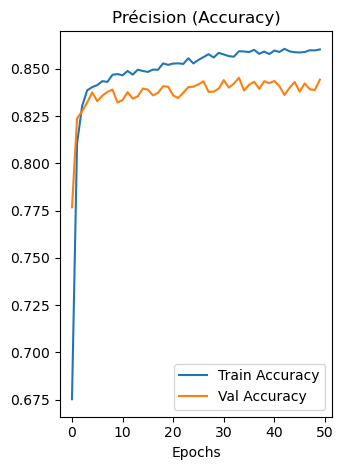

In [10]:
import matplotlib.pyplot as plt

plt.subplot(1, 2, 2)
plt.plot(V1.history['accuracy'], label='Train Accuracy')
plt.plot(V1.history['val_accuracy'], label='Val Accuracy')
plt.title('Précision (Accuracy)')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

Model Improvement

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Modèle amélioré
model2 = Sequential([
    Dense(64, activation='relu', input_shape=(9,)),  # ← +32 neurones
    Dense(64, activation='relu'),                    # ← +1 couche
    Dense(32, activation='relu'),
    Dense(9, activation='softmax')
])

model2.compile(optimizer='adam', 
               loss='categorical_crossentropy', 
               metrics=['accuracy'])

print("Modèle 2 (amélioré) créé!")
model2.summary()

Modèle 2 (amélioré) créé!


c:\Users\segui\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,177 (28.04 KB)

 Trainable params: 7,177 (28.04 KB)

 Non-trainable params: 0 (0.00 B)

Early Stopping

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',        # Surveille perte validation
    patience=7,               # Attend 7 epochs sans amélioration
    restore_best_weights=True  # Remet meilleurs poids
)

Training Model 2

In [17]:
# Entraînement amélioré
history2 = model2.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=100,           # ← +50 epochs
    batch_size=32,        # ← Plus petit batch = plus précis
    verbose=1
)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7468 - loss: 0.6728 - val_accuracy: 0.8202 - val_loss: 0.3989
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8342 - loss: 0.3188 - val_accuracy: 0.8341 - val_loss: 0.3017
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8380 - loss: 0.2885 - val_accuracy: 0.8332 - val_loss: 0.2829
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8377 - loss: 0.2817 - val_accuracy: 0.8356 - val_loss: 0.2824
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8431 - loss: 0.2772 - val_accuracy: 0.8353 - val_loss: 0.2789
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8432 - loss: 0.2735 - val_accuracy: 0.8429 - val_loss: 0.2741
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8451 - loss: 0.2708 - val_accuracy: 0.8380 - val_loss: 0.2722
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8471

Model 1 vs Model 2 Comparison

In [18]:
# Modèle 1 (original)
loss1, acc1 = model.evaluate(x_test, y_test_cat, verbose=0)

# Modèle 2 (amélioré)  
loss2, acc2 = model2.evaluate(x_test, y_test_cat, verbose=0)

print("Modèle 1:", f"{acc1*100:.1f}%")
print("Modèle 2:", f"{acc2*100:.1f}%")
print(f"Amélioration: {((acc2-acc1)/acc1*100):+.1f}%")

Modèle 1: 84.8%
Modèle 2: 85.3%
Amélioration: +0.6%


Part 2: Train the Model to Play Against Itself

Data Functions

In [19]:
import numpy as np
import random

def get_move(model, state, random_perc=0.2):
    if np.random.rand() < random_perc:
        zero_indices = [i for i, x in enumerate(state) if x == 0]

        if not zero_indices:
            return None

        return random.choice(zero_indices)

    else:
        predictions = model.predict(np.array([state]), verbose=0)
        cases_en_ordre = np.argsort(predictions[0])
        selection = len(cases_en_ordre) - 1
        while selection >= 0 and state[cases_en_ordre[selection]] != 0:
            selection -= 1
        if selection < 0:
            return None
        return cases_en_ordre[selection]


def check_winner(board):
    n = int(len(board) ** 0.5)
    # Check rows
    for i in range(0, len(board), n):
        if board[i] != 0 and all(board[i] == board[i + j] for j in range(1, n)):
            return board[i]

    # Check columns
    for i in range(n):
        if board[i] != 0 and all(board[i] == board[i + j * n] for j in range(1, n)):
            return board[i]

    # Check diagonal from top-left to bottom-right
    if board[0] != 0 and all(board[0] == board[(n + 1) * j] for j in range(1, n)):
        return board[0]

    # Check diagonal from top-right to bottom-left
    if board[n - 1] != 0 and all(board[n - 1] == board[(n - 1) * (j + 1)] for j in range(1, n)):
        return board[n - 1]

    return 0


def play_game(model_A, model_B, random_perc=0.2):
    X_moves = []
    O_moves = []
    current_state = [0, 0, 0, 0, 0, 0, 0, 0, 0]

    for i in range(9):
        if i % 2 == 0:
            next_move = get_move(model_A, current_state, random_perc)
            X_moves.append((current_state.copy(), next_move))
            current_state[next_move] = 1
        else:
            next_move = get_move(model_B, current_state, random_perc)
            O_moves.append((current_state.copy(), next_move))
            current_state[next_move] = -1

        winner = check_winner(current_state)
        if winner == 1:
            return 1, X_moves
        elif winner == -1:
            return -1, O_moves

    return 0, []

Winning Move Collection

In [20]:
import pandas as pd
import numpy as np

n = 500                    # 500 parties
modele2 = model2   

winning_moves = []
for i in range(n):
    winner, moves = play_game(modele2, modele2, 0.2)
    
    if winner != 0:          # Seulement si y'a un gagnant
        winning_moves.extend(moves)
    
    if i % 100 == 0:
        print(f"{i}/{n}")

# Créer colonnes parfaites
column_names = [f'cell_{i}' for i in range(9)]
column_names.append('move')

# DataFrame + CSV
df_winner = pd.DataFrame([row + [label] for row, label in winning_moves], 
                        columns=column_names)
df_winner.to_csv('winner_moves.csv', index=False)

print(f"✅ {len(df_winner)} coups gagnants sauvés !")
print("📁 Fichier: winner_moves.csv")
print(df_winner.head())

0/500
100/500
200/500
300/500
400/500
✅ 1668 coups gagnants sauvés !
📁 Fichier: winner_moves.csv
   cell_0  cell_1  cell_2  cell_3  cell_4  cell_5  cell_6  cell_7  cell_8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0      -1       0       1       0       0       0       0   
2       0       0      -1      -1       1       0       1       0       0   
3      -1       0      -1      -1       1       0       1       0       1   
4       0       0       0       0       0       0       0       0       0   

   move  
0     4  
1     6  
2     8  
3     7  
4     6  


Results Verification

In [ ]:
print(f"Lignes: {len(df_winner)}")
print(f"Format: {df_winner.shape}")
print(df_winner.head(5))

Lignes: 1668
Format: (1668, 10)
    cell_0  cell_1  cell_2  cell_3  cell_4  cell_5  cell_6  cell_7  cell_8  \
0        0       0       0       0       0       0       0       0       0   
1        0       0      -1       0       1       0       0       0       0   
2        0       0      -1      -1       1       0       1       0       0   
3       -1       0      -1      -1       1       0       1       0       1   
4        0       0       0       0       0       0       0       0       0   
5        0       0       0       0      -1       0       1       0       0   
6       -1       0       0       0      -1       0       1       0       1   
7       -1       0       1      -1      -1       0       1       0       1   
8        0       0       0       0       1       0       0       0       0   
9        0       0      -1       0       1       0       1       0       0   
10       1       0      -1       0       1       0       1       0      -1   
11       1      -1      -1      

Winning Moves Overview

In [23]:
print(f"Lignes: {len(df_winner)}")
print(f"Format: {df_winner.shape}")
print(df_winner.head(3))
print("\nStatistiques rapides :")
print(df_winner['move'].value_counts().head())  # Cases les plus jouées
print(f"Cases vides moyennes: {(df_winner.iloc[:,:9]==0).sum(axis=1).mean():.1f}")

Lignes: 1668
Format: (1668, 10)
   cell_0  cell_1  cell_2  cell_3  cell_4  cell_5  cell_6  cell_7  cell_8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0      -1       0       1       0       0       0       0   
2       0       0      -1      -1       1       0       1       0       0   

   move  
0     4  
1     6  
2     8  

Statistiques rapides :
move
8    281
2    281
5    240
1    231
6    165
Name: count, dtype: int64
Cases vides moyennes: 5.5


Training the New Model (Model 3).

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Charger winner_moves.csv (tes 1652 coups gagnants)
df_winner = pd.read_csv("winner_moves.csv")
print(f"Données générées: {df_winner.shape[0]} coups gagnants")

# Préparation des données
X = df_winner.drop("move", axis=1).values  # 9 cases du plateau
y = df_winner["move"].values               # Case jouée (0-8)

# One-hot encoding pour 9 classes
y_cat = to_categorical(y, num_classes=9)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

# Nouveau modèle (MODELE3)
modele3 = Sequential([
    Input(shape=(9,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'), 
    Dense(32, activation='relu'),
    Dense(9, activation='softmax')  # 9 cases possibles
])

modele3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

# Entraînement
history = modele3.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Évaluation
loss, acc = modele3.evaluate(X_test, y_test, verbose=0)
print(f"✅ MODELE3 - Accuracy: {acc:.3f}, Loss: {loss:.3f}")


Données générées: 1668 coups gagnants
Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3478 - loss: 2.0251 - val_accuracy: 0.4850 - val_loss: 1.7821
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5022 - loss: 1.6378 - val_accuracy: 0.5509 - val_loss: 1.4581
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5855 - loss: 1.3589 - val_accuracy: 0.5898 - val_loss: 1.2697
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6544 - loss: 1.1583 - val_accuracy: 0.6497 - val_loss: 1.1631
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6972 - loss: 1.0224 - val_accuracy: 0.6766 - val_loss: 1.1292
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7316 - loss: 0.9442 - val_accuracy: 0.6826 - val_loss: 1.1026
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7421 - loss: 0.8881 - val_accuracy: 0.6946 - val_loss: 1.0649
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7586 - 

Model Comparison on Self-Play Games

In [25]:
def compare_models(m1, m2, n):
    results = {'modeleA': 0 , 'modeleB': 0, 'draws': 0}

    for i in range(n):

        # Model A starts
        winner, _ = play_game(m1, m2, 0)
        if winner == 1:
            results['modeleA'] += 1
        elif winner == -1:
            results['modeleB'] += 1
        else:
            results['draws'] += 1
        

        # Model B starts
        winner, _ = play_game(m2, m1, 0)
        if winner == 1:
            results['modeleB'] += 1
        elif winner == -1:
            results['modeleA'] += 1
        else:
            results['draws'] += 1

    return results


Model 2 vs. Model 3 Comparison

In [26]:
# Appel CORRECT de TA fonction (celle que tu as déjà)
results = compare_models(modele2, modele3, 100)  # n=100

print("\n" + "="*50)
print("🏆 COMPARAISON MODELE2 vs MODELE3")
print("="*50)
print(f"Victories MODELE2 (m1) : {results['modeleA']}")
print(f"Victories MODELE3 (m2) : {results['modeleB']}")
print(f"Égalités               : {results['draws']}")
print(f"Total                  : {sum(results.values())}")

# Pourcentage
total_decisive = results['modeleA'] + results['modeleB']
if total_decisive > 0:
    win_rate_m3 = (results['modeleB'] / total_decisive) * 100
    print(f"Taux victoire MODELE3  : {win_rate_m3:.1f}%")
else:
    print("💭 Égalités totales")


🏆 COMPARAISON MODELE2 vs MODELE3
Victories MODELE2 (m1) : 0
Victories MODELE3 (m2) : 200
Égalités               : 0
Total                  : 200
Taux victoire MODELE3  : 100.0%
